In [1]:
! pip install ultralytics opencv-python pyyaml numpy pandas scikit-learn torch matplotlib seaborn paddleocr paddlepaddle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
  

In [2]:
import cv2, os, random, shutil, zipfile, yaml, csv, math, paddle, threading, time, json, subprocess
import numpy as np
from pathlib import Path
from tqdm import tqdm
from typing import List, Tuple, Optional, Dict
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from uuid import uuid4
from concurrent.futures import ThreadPoolExecutor, as_completed
from ultralytics import YOLO
from paddleocr import PaddleOCR


# configs
BASE_DIR = Path("/content/data/")
ARCHIVE_FILE = Path("/content/archive.zip")
DATASET_DIR = (BASE_DIR / "cleaned")
YOLO_DIR = (BASE_DIR / "processed")
OCR_DIR = (BASE_DIR / "ocr_processed")

YAML_PATH = ("data.yaml")
DATA_YAML = (YOLO_DIR / "data.yaml")
MODEL_ARCH = "models/yolov8m.pt"

FOLDERS = ["google_images", "video_images", "State-wise_OLX"]
PRO_FOLDERS = ["train", "valid", "test"]
SPLIT_RATIOS = (0.8, 0.1, 0.1)

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
PRO_IMG_EXTENSIONS = {".jpg", ".jpeg", ".png"}
ANNOTATION_EXT = ".xml"
YOLO_ANNOTATION_EXT = ".txt"

RUN_NAME = "anpr_v1"
RUN_NAME2 = "anpr_v2"
EPOCHS_DRY = 1
EPOCHS_HALF = 10
EPOCHS_FULL = 50
IMG_SIZE = 640
SAMPLES_TO_VISUALIZE = 5

/usr/local/lib/python3.11/dist-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
colab_content = "/content/"
folders = [
    "models",
    "configs"
]

# Create them
for folder in folders:
    full_path = os.path.join(colab_content, folder)
    os.makedirs(full_path, exist_ok=True)
    print(f"[INFO] Created: {full_path}")

[INFO] Created: /content/models
[INFO] Created: /content/configs


In [4]:
def extract_archive(archive_file: Path, extract_to: Path):
    """Extract the archive.zip file into the specified directory."""
    try:
        extract_to.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive_file, 'r') as zip_ref:
            zip_ref.extractall(extract_to)

        print(f"[INFO] Extracted archive: {archive_file} -> {extract_to}")
    except Exception as e:
        print(f"[ERROR] Failed to extract archive: {e}")

def collect_images(base_dir, folders, img_extensions=IMG_EXTENSIONS):
    """Collect all image paths from the specified folders and subfolders."""
    all_images = []

    try:
        for folder in folders:
            folder_path = base_dir / folder

            if not folder_path.exists():
                print(f"[WARN] Folder not found: {folder_path}")
                continue

            for root, _, files in os.walk(folder_path):
                for file in files:
                    if Path(file).suffix.lower() in img_extensions:
                        all_images.append(Path(root) / file)

        print(f"[INFO] Total images collected: {len(all_images)}")
    except Exception as e:
        print(f"[ERROR] Failed to collect images: {e}")
    return all_images

def split_dataset(images, ratios):
    """Split image paths into train, valid, and test sets."""
    try:
        random.shuffle(images)
        n_total = len(images)

        n_train = int(ratios[0] * n_total)
        n_valid = int(ratios[1] * n_total)

        train_set = images[:n_train]
        valid_set = images[n_train:n_train + n_valid]
        test_set = images[n_train + n_valid:]

        print(f"[INFO] Split: Train={len(train_set)}, Valid={len(valid_set)}, Test={len(test_set)}")
        return train_set, valid_set, test_set
    except Exception as e:
        print(f"[ERROR] Failed to split dataset: {e}")
        return [], [], []

def copy_files_with_annotations(images, target_dir, annotation_ext=ANNOTATION_EXT):
    """Copy images and their corresponding annotation files to the target directory."""
    try:
        target_dir.mkdir(parents=True, exist_ok=True)

        for img_path in images:
            try:
                # copy img
                shutil.copy(img_path, target_dir / img_path.name)

                # copy annotation (same name with .xml ext.)
                annotation_path = img_path.with_suffix(annotation_ext)

                if annotation_path.exists():
                    shutil.copy(annotation_path, target_dir / annotation_path.name)
                else:
                    print(f"[WARN] No annotation for {img_path.name}")

            except Exception as e:
                print(f"[ERROR] Failed to copy {img_path.name}: {e}")

    except Exception as e:
        print(f"[ERROR] Failed to copy files to {target_dir}: {e}")


def prepare_dataset(base_dir=BASE_DIR, output_dir=DATASET_DIR, folders=FOLDERS, split_ratios=SPLIT_RATIOS):
    """Main pipeline to prepare dataset."""
    try:
        # Step 0: Extract archive
        extract_archive(ARCHIVE_FILE, BASE_DIR)

        # Step 1: collect all imgs
        images = collect_images(base_dir, folders)
        if not images:
            print("[ERROR] No images found. Exiting...")
            return

        # Step 2: split dataset
        train_set, valid_set, test_set = split_dataset(images, split_ratios)

        # Step 3: copy files
        print("[INFO] Copying Train set...")
        copy_files_with_annotations(train_set, output_dir / "train")

        print("[INFO] Copying Valid set...")
        copy_files_with_annotations(valid_set, output_dir / "valid")

        print("[INFO] Copying Test set...")
        copy_files_with_annotations(test_set, output_dir / "test")

        print("[INFO] Dataset prepared successfully!")
    except Exception as e:
        print(f"[ERROR] Dataset preparation failed: {e}")

def check_annotations(split_dir, img_extensions=IMG_EXTENSIONS, annotation_ext=ANNOTATION_EXT):
    """Check images and annotation files in the split directory."""
    try:
        print(f"\n[INFO] Checking directory: {split_dir}")

        images = [f for f in split_dir.iterdir() if f.suffix.lower() in img_extensions]
        annotations = [f for f in split_dir.iterdir() if f.suffix.lower() == annotation_ext]

        image_names = {f.stem for f in images}
        annotation_names = {f.stem for f in annotations}

        # find missing annotations
        missing_annotations = image_names - annotation_names
        missing_images = annotation_names - image_names  # shouldn't exist ideally

        print(f"  Total Images: {len(images)}")
        print(f"  Total Annotations: {len(annotations)}")

        if missing_annotations:
            print(f"  [WARN] Missing annotations for {len(missing_annotations)} images:")
            for name in sorted(missing_annotations):
                print(f"    - {name}")
        else:
            print("  [INFO] All images have corresponding annotations.")

        if missing_images:
            print(f"  [WARN] Found annotations with no matching images:")
            for name in sorted(missing_images):
                print(f"    - {name}")

    except Exception as e:
        print(f"[ERROR] Failed to check {split_dir}: {e}")


def verify_dataset(dataset_dir=DATASET_DIR):
    """Verify annotations in train, valid, and test directories."""
    try:
        for split in ["train", "valid", "test"]:
            split_dir = dataset_dir / split
            if not split_dir.exists():
                print(f"[WARN] Split directory not found: {split_dir}")
                continue
            check_annotations(split_dir)
        print("\n[INFO] Dataset verification complete.")
    except Exception as e:
        print(f"[ERROR] Dataset verification failed: {e}")


def run_stage_01():
    prepare_dataset()
    verify_dataset()


def create_yolo_dirs(pro_folders=PRO_FOLDERS, output_dir=YOLO_DIR):
    for split in pro_folders:
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

def convert_xml_to_yolo(xml_file, img_path, label_path):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        img_w = int(root.find("size/width").text)
        img_h = int(root.find("size/height").text)

        yolo_labels = []
        for obj in root.findall("object"):
            bbox = obj.find("bndbox")
            if bbox is None:
                print(f"[WARN] No bounding box in {xml_file}")
                continue

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            # convert to the format that yolo accepts
            x_center = (((xmin + xmax) / 2) / img_w)
            y_center = (((ymin + ymax) / 2) / img_h)
            w = ((xmax - xmin) / img_w)
            h = ((ymax - ymin) / img_h)

            yolo_labels.append(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        if not yolo_labels:
            print(f"[WARN] No objects found in {xml_file}")

        # write to label file
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_labels))
    except Exception as e:
        print(f"[ERROR] Failed to convert {xml_file}: {e}")


def preprocess_dataset(pro_folders=PRO_FOLDERS, dataset_dir=DATASET_DIR, output_dir=YOLO_DIR, pro_img_extensions=PRO_IMG_EXTENSIONS, annotation_ext=ANNOTATION_EXT, yolo_annotation_ext=YOLO_ANNOTATION_EXT):

    print("[INFO] Starting pre-processing...")
    create_yolo_dirs()
    print("[INFO] Created necessary directories for YOLO format.")

    for split in pro_folders:
        img_dir = dataset_dir / split
        for img_file in img_dir.iterdir():
            if img_file.suffix.lower() not in pro_img_extensions:
                continue

            sml_file = img_file.with_suffix(annotation_ext)
            target_img_path = output_dir / "images" / split / img_file.name
            target_lbl_path = output_dir / "labels" / split / (img_file.stem + yolo_annotation_ext)

            shutil.copy(img_file, target_img_path)
            if sml_file.exists():
                convert_xml_to_yolo(sml_file, img_file, target_lbl_path)
            else:
                print(f"[WARN] No annotation found for {img_file.name}, creating empty label.")
                open(target_lbl_path, "w").close()

    print("[INFO] Pre-processing completed!")


def validate_yolo_dataset(pro_folders, output_dir):
    """
    Validate the YOLO dataset structure:
    - Ensures images and labels are paired correctly
    - Counts number of images and annotations per split
    """
    print("[INFO] Starting YOLO dataset validation...")

    for split in pro_folders:
        img_dir = output_dir / "images" / split
        lbl_dir = output_dir / "labels" / split

        if not img_dir.exists() or not lbl_dir.exists():
            print(f"[ERROR] Missing directory for split: {split}")
            continue

        images = [f for f in img_dir.iterdir() if f.is_file()]
        labels = [f for f in lbl_dir.iterdir() if f.is_file()]

        image_names = {f.stem for f in images}
        label_names = {f.stem for f in labels}

        missing_labels = image_names - label_names
        extra_labels = label_names - image_names

        print(f"\n[INFO] Split: {split}")
        print(f"  Total Images: {len(images)}")
        print(f"  Total Labels: {len(labels)}")

        if missing_labels:
            print(f"  [WARN] Missing annotations for {len(missing_labels)} images:")
            for name in sorted(missing_labels):
                print(f"    - {name}")

        if extra_labels:
            print(f"  [WARN] Labels without matching images ({len(extra_labels)}):")
            for name in sorted(extra_labels):
                print(f"    - {name}")

    print("\n[INFO] YOLO dataset validation complete.")


def generate_data_yaml(output_dir, yaml_path=YAML_PATH):
    """
    Generate YOLOv8 data.yaml for training.
    """
    data_config = {
        "train": str((output_dir / "images" / "train").resolve()),
        "val": str((output_dir / "images" / "valid").resolve()),
        "test": str((output_dir / "images" / "test").resolve()),
        "nc": 1,  # number of classes
        "names": ["license_plate"]  # class names
    }

    yaml_path = Path(output_dir) / yaml_path
    with open(yaml_path, "w") as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print(f"[INFO] data.yaml created at: {yaml_path}")
    return yaml_path


def run_stage_02():
    preprocess_dataset()
    validate_yolo_dataset(PRO_FOLDERS, YOLO_DIR)
    generate_data_yaml(YOLO_DIR)


def parse_annotation(xml_file: Path):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        image_file = root.find("filename").text

        annotations = []
        for obj in root.findall("object"):
            text = obj.find("name").text.strip()
            bbox = obj.find("bndbox")
            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            points = [[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]]
            annotations.append({
                "transcription": text,
                "points": points
            })

        return image_file, annotations
    except Exception as e:
        print(f"[ERROR] Parsing failed for {xml_file}: {e}")
        return None, None


def create_split_file(split: str, base_dir: Path, output_txt: Path, images_out_dir: Path):
    split_dir = base_dir / split
    images_out_dir.mkdir(parents=True, exist_ok=True)

    with open(output_txt, "w", encoding="utf-8") as f:
        for xml_file in split_dir.glob("*.xml"):
            image_name, annotations = parse_annotation(xml_file)
            if not image_name or not annotations:
                continue

            image_path = split_dir / image_name
            if not image_path.exists():
                print(f"[WARN] Missing image file: {image_path}")
                continue

            # Copy image to PaddleOCR structure
            dest_image_path = images_out_dir / image_name
            shutil.copy(image_path, dest_image_path)

            # Write label entry
            ann_str = json.dumps(annotations, ensure_ascii=False)
            f.write(f"{str(dest_image_path)}\t{ann_str}\n")

    print(f"[INFO] Generated label file: {output_txt}")


def create_paddle_ocr_data(base_dir=DATASET_DIR, output_dir=OCR_DIR, folder_names=PRO_FOLDERS):
    labels_dir = output_dir / "labels"
    images_dir = output_dir / "images"
    labels_dir.mkdir(parents=True, exist_ok=True)

    for split in folder_names:
        output_txt = labels_dir / f"{split}.txt"
        split_images_dir = images_dir / split
        create_split_file(split, base_dir, output_txt, split_images_dir)

def verify_split_alignment(images_dir: Path, label_file: Path):
    if not label_file.exists():
        print(f"[ERROR] Missing label file: {label_file}")
        return

    image_paths = list(images_dir.glob("*.*"))
    label_lines = label_file.read_text(encoding="utf-8").strip().splitlines()

    label_img_paths = []
    for line in label_lines:
        try:
            image_path, ann = line.split("\t", 1)
            label_img_paths.append(Path(image_path).name)
        except Exception as e:
            print(f"[WARN] Skipping malformed label line in {label_file.name}: {e}")

    image_names = {img.name for img in image_paths}
    label_names = set(label_img_paths)

    extra_images = image_names - label_names
    missing_images = label_names - image_names

    print(f"\n--- Split: {label_file.stem} ---")
    print(f"Total images found: {len(image_names)}")
    print(f"Total labels found: {len(label_names)}")
    print(f"Extra images without labels: {len(extra_images)}")
    print(f"Missing images referenced in labels: {len(missing_images)}")

    if extra_images:
        print(" -> Unused image files:")
        for name in sorted(extra_images):
            print(f"    - {name}")

    if missing_images:
        print(" -> Missing image files (mentioned in labels but not found):")
        for name in sorted(missing_images):
            print(f"    - {name}")

def verify_paddle_ocr_data(output_dir: Path):
    images_root = output_dir / "images"
    labels_root = output_dir / "labels"

    for split in ["train", "valid", "test"]:
        split_images_dir = images_root / split
        split_label_file = labels_root / f"{split}.txt"
        verify_split_alignment(split_images_dir, split_label_file)

def run_stage_03():
    create_paddle_ocr_data()
    verify_paddle_ocr_data(OCR_DIR)

In [5]:
run_stage_01()
run_stage_02()
run_stage_03()

[INFO] Extracted archive: /content/archive.zip -> /content/data
[INFO] Total images collected: 1698
[INFO] Split: Train=1358, Valid=169, Test=171
[INFO] Copying Train set...
[INFO] Copying Valid set...
[INFO] Copying Test set...
[INFO] Dataset prepared successfully!

[INFO] Checking directory: /content/data/cleaned/train
  Total Images: 1358
  Total Annotations: 1356
  [INFO] All images have corresponding annotations.

[INFO] Checking directory: /content/data/cleaned/valid
  Total Images: 169
  Total Annotations: 169
  [INFO] All images have corresponding annotations.

[INFO] Checking directory: /content/data/cleaned/test
  Total Images: 171
  Total Annotations: 171
  [INFO] All images have corresponding annotations.

[INFO] Dataset verification complete.
[INFO] Starting pre-processing...
[INFO] Created necessary directories for YOLO format.
[INFO] Pre-processing completed!
[INFO] Starting YOLO dataset validation...

[INFO] Split: train
  Total Images: 1358
  Total Labels: 1356

[INFO]

In [6]:
shutil.rmtree('/content/data/State-wise_OLX')
shutil.rmtree('/content/data/google_images')
shutil.rmtree('/content/data/video_images')
shutil.rmtree('/content/data/cleaned')

shutil.rmtree('/content/sample_data')

In [41]:
class ANPRPipeline:
    def _load_models(self):
        self.yolo_model = YOLO(str(self.model_path))

    def _reset_stats(self):
        self.stats = {
            'total_processed': 0,
            'successful_ocr': 0,
            'failed_ocr': 0,
            'no_detections': 0
        }

    def __init__(self, model_path: str, output_dir: str, csv_path: str):
        self.model_path = Path(model_path)
        self.output_dir = Path(output_dir)
        self.csv_path = Path(csv_path)

        self._local = threading.local()  # For OCR instance
        self._load_models()
        self._reset_stats()

    def _get_ocr_instance(self):
        if not hasattr(self._local, 'ocr'):
            self._local.ocr = PaddleOCR(
                # use_doc_orientation_classify=False,
                # use_doc_unwarping=False,
                use_textline_orientation=False,
                lang='en',
                text_det_limit_side_len=1280,
                text_det_limit_type='max',
                text_recognition_batch_size=6,
            )
        return self._local.ocr

    def _validate_crop(self, cropped_img: np.ndarray, min_area: int = 100) -> bool:
        if cropped_img is None or cropped_img.size == 0:
            return False

        h, w = cropped_img.shape[:2]
        if h < 10 or w < 20 or (h * w) < min_area:
            return False

        # Check if image is not completely black or white
        mean_val = np.mean(cropped_img)
        if mean_val < 5 or mean_val > 250:
            return False

        return True

    def show_images(self, images: List[np.ndarray], titles: List[str]):
        plt.figure(figsize=(15, 5))
        for i, (img, title) in enumerate(zip(images, titles)):
            plt.subplot(1, len(images), i + 1)
            if len(img.shape) == 2:  # grayscale
                plt.imshow(img, cmap='gray')
            else:
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(title)
            plt.axis('off')
        plt.show()

    def _convert_to_gray(self, img):
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    def _apply_clahe(self, img):
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        return clahe.apply(img)

    def _apply_histeq(self, img):
        return cv2.equalizeHist(img)

    def _denoise(self, img):
        return cv2.bilateralFilter(img, 9, 75, 75)

    def _apply_morph(self, img):
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
        return cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    def preprocess_plate_variants(self, cropped_img: np.ndarray) -> Optional[Dict[str, np.ndarray]]:
        try:
            if not self._validate_crop(cropped_img):
                return None

            try:
                variants = {"raw": cropped_img}

                gray = self._convert_to_gray(cropped_img)
                variants["gray"] = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

                clahe_img = self._apply_clahe(gray)
                variants["gray + clahe"] = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2BGR)

                hist_eq = self._apply_histeq(gray)
                variants["gray + histeq"] = cv2.cvtColor(hist_eq, cv2.COLOR_GRAY2BGR)

                denoised = self._denoise(clahe_img)
                variants["clahe + denoised"] = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)

                morph_img = self._apply_morph(clahe_img)
                variants["morphological"] = cv2.cvtColor(morph_img, cv2.COLOR_GRAY2BGR)
            except Exception as e:
                print(f"[ERROR] Preprocessing failed: {e}")

            self.show_images(
              [
                  cropped_img,
                  variants["gray"],
                  variants["gray + clahe"],
                  variants["gray + histeq"],
                  variants["clahe + denoised"],
                  variants["morphological"],
              ],
              [
                  "Cropped Img",
                  "Gray",
                  "Gray + CLAHE",
                  "Gray + Hist. Eq. Filter",
                  "CLACHE + Denoised",
                  "Morphological Gradient",
              ]
            )

            return variants
        except Exception as e:
            print(f"[DEBUG] Preprocessing variants failed: {e}")
            return None

    def _parse_dict_style(self, result):
        if isinstance(result, list) and len(result) > 0 and isinstance(result[0], dict):
            if 'rec_texts' in result[0] and 'rec_scores' in result[0]:
                texts = result[0]['rec_texts']
                scores = result[0]['rec_scores']
                if texts and scores:
                    return texts[0], scores[0]
        raise ValueError("Invalid dict-style format")

    def _parse_list_style(self, result):
        if isinstance(result, list) and len(result) > 0 and isinstance(result[0], list):
            for item in result[0]:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    text_info = item[1] if len(item) > 1 else item[0]
                    if isinstance(text_info, (list, tuple)) and len(text_info) >= 2:
                        return text_info[0], text_info[1]
        raise ValueError("Invalid list-style format")

    def _parse_fallback_style(self, result) -> Tuple[str, float]:
        if isinstance(result, list) and len(result) > 0:
            item = result[0]
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                return item[0], item[1]
        raise ValueError("Invalid fallback format")

    def parse_ocr_result(self, result, variant_name: str):
        for parser in [self._parse_dict_style, self._parse_list_style, self._parse_fallback_style]:
            try:
                text, conf = parser(result)
                if text and isinstance(conf, (float, int)) and conf > 0:
                    return str(text), float(conf)
            except Exception:
                continue
        print(f"[DEBUG] Could not parse OCR result for '{variant_name}'")
        return "", 0.0

    def _select_best_result(self, variant_results, current_best_text, current_best_conf, current_best_variant):
        best_text, best_score, best_variant = current_best_text, current_best_conf, current_best_variant
        for text, score, variants in variant_results:
            if score > best_score:
                best_text, best_score = text, score
        return best_text, best_score, best_variant

    def analyze_and_combine_results(self, variant_results, current_best_text, current_best_conf, current_best_variant):
        if not variant_results:
            return current_best_text, current_best_conf, current_best_variant

        return self._select_best_result(variant_results, current_best_text, current_best_conf, current_best_variant)

    def clean_plate_text(self, text: str) -> str:
        if not text:
            return ""

        # Remove common OCR artifacts
        cleaned = text.strip()

        # Remove spaces and special characters (license plates typically don't have them)
        cleaned = ''.join(c for c in cleaned if c.isalnum())

        return cleaned.upper()

    def _run_ocr_on_variants(self, variants):
        results = []
        best_text, best_conf, best_variant = "", 0.0, ""

        ocr = self._get_ocr_instance()
        for name, img in variants.items():

            try:
                result = ocr.predict(img)
                if not result or not result[0]:
                  print(f"[DEBUG] OCR returned no results for '{name}'.")
                  continue

                text, conf = self.parse_ocr_result(result, name)
                if text and conf > 0:
                    cleaned_text = self.clean_plate_text(text)
                    print(f"[{name.upper()}] -> Text: '{text}' -> Cleaned: '{cleaned_text}', Conf: {conf:.4f}")

                    results.append((cleaned_text, conf, name))
                    if conf > best_conf and len(cleaned_text) > 0:
                            best_text, best_conf, best_variant = cleaned_text, conf, name
            except Exception as e:
                print(f"[ERROR] OCR failed for variant '{name}': {e}")
        return results, best_text, best_conf, best_variant

    def safe_ocr_predict_variants(self, cropped_img):
        if cropped_img is None:
              return "", 0.0, ""

        variants = self.preprocess_plate_variants(cropped_img)
        if not variants:
            return "", 0.0, ""

        variant_results, text, conf, name = self._run_ocr_on_variants(variants)
        best_text, best_conf, best_variant = text or "", conf or 0.0, name or ""

        if best_text and len(best_text) < 6:  # Most license plates have 6+ characters
            print(f"[INFO] '{best_text}' using '{best_variant}' seems short. So now, analyzing all results...")
            best_text, best_conf, best_variant = self.analyze_and_combine_results(variant_results, best_text, best_conf, best_variant)

        return best_text, best_conf, best_variant, variants

    def _pad_and_crop(self, img: np.ndarray, box: np.ndarray, img_path: str):
        try:
            # Handle both 4-element (x1,y1,x2,y2) and 5-element (x1,y1,x2,y2,conf) boxes
            if len(box) >= 4:
                x1, y1, x2, y2 = map(int, box[:4])
            else:
                print(f"[ERROR] Invalid box format: {box}")
                return Path(img_path).name, ""

            # Validate bounding box
            h, w = img.shape[:2]

            # Add padding to avoid cutting off characters (especially last one)
            padding_x = int((x2 - x1) * 0.05)  # 5% horizontal padding
            padding_y = int((y2 - y1) * 0.1)   # 10% vertical padding

            x1 = max(0, x1 - padding_x)
            y1 = max(0, y1 - padding_y)
            x2 = min(w, x2 + padding_x)
            y2 = min(h, y2 + padding_y)

            if x2 <= x1 or y2 <= y1:
                return Path(img_path).name, ""

            # Return extracted crop
            return img[y1:y2, x1:x2]
        except Exception as e:
            print(f"[ERROR] Detection processing failed for {img_path}: {e}")
            return Path(img_path).name, ""

    def _save_debug_images(self, img_path: str, det_idx: int, tag: str, result, sub_dir_name: str="ocr_debug_images"):
        debug_subdir = self.output_dir / (sub_dir_name)
        debug_subdir.mkdir(parents=True, exist_ok=True)

        debug_tag_subsubdir = debug_subdir / str(tag)
        debug_tag_subsubdir.mkdir(parents=True, exist_ok=True)

        debug_path = debug_tag_subsubdir / (f"{Path(img_path).stem}_{det_idx}.jpg")
        print(f"[INFO] Debug image saved to: '{debug_path}")
        return cv2.imwrite(str(debug_path), result)

    def process_single_detection(self, img: np.ndarray, box: np.ndarray, img_path: str, detection_idx: int, conf_threshold_rec) -> Tuple[str, str]:
        try:
            print(f"[INFO] Running OCR on {Path(img_path).name}...")
            cropped = self._pad_and_crop(img, box, img_path)
            # Perform variant-based OCR
            text, conf, variant_name, variants = self.safe_ocr_predict_variants(cropped)

            # Debug: Save the cropped region to visually inspect
            debug_crop_path = self._save_debug_images(img_path, detection_idx, "crop", cropped)

            # Debug: Save best variant's image
            if text and conf >= conf_threshold_rec:
                debug_best_variant_path = self._save_debug_images(img_path, detection_idx, str(variant_name), variants[variant_name])

            if text:
                self.stats['successful_ocr'] += 1
                print(f"[SUCCESS] {Path(img_path).name}: '{text}', '{conf:.4f}', (Length: {len(text)})")
            else:
                self.stats['failed_ocr'] += 1
                print(f"[WARN] No text detected in {Path(img_path).name}")

            return Path(img_path).name, text
        except Exception as e:
            self.stats['failed_ocr'] += 1
            print(f"[ERROR] Detection processing failed for {img_path}: {e}")
            return Path(img_path).name, ""

    def _annotate_image(self, img, box, result):
        x1, y1, x2, y2 = map(int, box[:4])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, result[1], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    def _save_annotated_images(self, img: np.ndarray, img_path, subdir_name: str="ocr_output_images"):
        output_path = self.output_dir / (subdir_name)
        output_path.mkdir(parents=True, exist_ok=True)

        output_subdir_path = output_path / (Path(img_path).name)
        print(f"[INFO] Annotated image saved to: '{output_subdir_path}'")
        return cv2.imwrite(str(output_subdir_path), img)

    def batch_detect_plates(self, images, image_paths, conf_threshold_det, conf_threshold_rec):
        batch_results = []

        try:
            print(f"[INFO] Running YOLO detection on batch of {len(images)} images...")
            yolo_results = self.yolo_model.predict(
                source=images,
                conf=conf_threshold_det,
                save=False,
                verbose=False
            )
            for img, yolo_result, img_path in zip(images, yolo_results, image_paths):
                self.stats['total_processed'] += 1

                if yolo_result.boxes is None or len(yolo_result.boxes) == 0:
                    self.stats['no_detections'] += 1
                    print(f"[INFO] No plates detected in {Path(img_path).name}")
                    batch_results.append((Path(img_path).name, ""))
                    continue

                boxes = yolo_result.boxes.xyxy.cpu().numpy()
                for i, box in enumerate(boxes):
                    result = self.process_single_detection(img, box, img_path, i, conf_threshold_rec)
                    batch_results.append(result)
                    # Draw bounding box
                    self._annotate_image(img, box, result)

                output_path = self._save_annotated_images(img, img_path)
            return batch_results
        except Exception as e:
            print(f"[ERROR] Batch processing failed: {e}")
            for path in image_paths:
                batch_results.append((Path(path).name, ""))
            return batch_results

    def process_image_batches(self, image_paths: List[str], conf_threshold_det, conf_threshold_rec) -> List[Tuple[str, str]]:
        batch_results = []
        images, valid_paths = [], []

        try:
            for path in image_paths:
                img = cv2.imread(path)
                if img is not None:
                    images.append(img)
                    valid_paths.append(path)
                else:
                    print(f"[WARN] Could not load image: {path}")
                    batch_results.append((Path(path).name, ""))

            if not images:
                return batch_results

            batch_results = self.batch_detect_plates(images, valid_paths, conf_threshold_det, conf_threshold_rec)
            print(f"[DEBUG] Batch results received: {len(batch_results)} results")

            return batch_results
        except Exception as e:
            print(f"[ERROR] Batch processing failed: {e}")
            for path in image_paths:
                batch_results.append((Path(path).name, ""))

    def _seq_batch_processing(self, num_batches, batches, conf_threshold_det, conf_threshold_rec):
        all_results = []

        try:
            for i, batch in enumerate(tqdm(batches, desc="Processing Batches")):
                print(f"[INFO] Processing batch {i + 1}/{num_batches}...")
                results = self.process_image_batches(batch, conf_threshold_det, conf_threshold_rec)
                if results is None:
                    print(f"[ERROR] results returned None —> skipping.")
                    continue
                all_results.extend(results)
                print(f"[STATS] OCR Success: {self.stats['successful_ocr']}, Failures: {self.stats['failed_ocr']}, No Detections: {self.stats['no_detections']}")
        except Exception as e:
            print(f"[ERROR] Batch {i} failed: {e}")

    def _multi_threaded_batch_processing(self, batches, conf_threshold_det, conf_threshold_rec, max_workers):
        all_results = []
        try:
            with ThreadPoolExecutor(max_workers=4) as executor:
                futures = {executor.submit(self.process_image_batches, batch, conf_threshold_det, conf_threshold_rec): i for i, batch in enumerate(batches)}
                for future in as_completed(futures):
                    results = future.result()
                    if results is None:
                        print(f"[ERROR] results returned None —> skipping.")
                        continue
                    all_results.extend(results)
                    print(f"[STATS] OCR Success: {self.stats['successful_ocr']}, Failures: {self.stats['failed_ocr']}, No Detections: {self.stats['no_detections']}")
                return all_results
        except Exception as e:
            print(f"[ERROR] Batch {futures[future]} failed: {e}")

    def process_directory(self, img_dir: str, batch_size: int, conf_threshold_det: int, conf_threshold_rec: int, max_workers: int):
        img_dir = Path(img_dir)
        img_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

        # Collect image paths
        img_files = [
            str(img_dir / f) for f in os.listdir(img_dir)
            if f.lower().endswith(img_extensions)
        ]
        if not img_files:
            print(f"[WARN] No images found in {img_dir}")
            return

        self.output_dir.mkdir(parents=True, exist_ok=True)

        total_images = len(img_files)
        num_batches = math.ceil(total_images / batch_size)
        all_results = []

        print(f"[INFO] Starting directory processing: {total_images} images in {num_batches} batches")
        batches = [
            img_files[i:i + batch_size]
            for i in range(0, total_images, batch_size)
        ]

        # all_results = self._multi_threaded_batch_processing(batches, conf_threshold_det, conf_threshold_rec, max_workers)
        all_results = self._seq_batch_processing(num_batches, batches, conf_threshold_det, conf_threshold_rec)

        # Save CSV and final stats
        self.save_results(all_results)
        self.print_statistics()
        print(f"[SUCCESS] Dir Processed & Saved")

    def save_results(self, results: List[Tuple[str, str]]):
        try:
            self.csv_path.parent.mkdir(parents=True, exist_ok=True)

            with open(self.csv_path, 'w', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                writer.writerow(["image_name", "detected_plate"])
                writer.writerows(results)

            print(f"[INFO] Results saved to {self.csv_path}")
        except Exception as e:
            print(f"[ERROR] Failed to save CSV: {e}")

    def print_statistics(self):
        print("\n" + "="*50)
        print("PROCESSING STATISTICS")
        print("="*50)
        print(f"Total Images Processed: {self.stats['total_processed']}")
        print(f"Successful OCR: {self.stats['successful_ocr']}")
        print(f"Failed OCR: {self.stats['failed_ocr']}")
        print(f"No Detections: {self.stats['no_detections']}")

        if self.stats['total_processed']:
            success_rate = (self.stats['successful_ocr'] / self.stats['total_processed']) * 100
            print(f"Success Rate: {success_rate:.2f}%")
        print("="*50)

[INFO] Starting directory processing: 171 images in 15 batches


Processing Batches:   0%|          | 0/15 [00:00<?, ?it/s]

[INFO] Processing batch 1/15...
[INFO] Running YOLO detection on batch of 12 images...
[INFO] Running OCR on car-wbs-KL54H369_00000.jpeg...


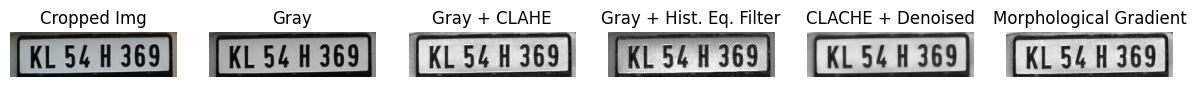

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None)
The model(UVDoc) is not supported to run in MKLDNN mode! Using `paddle` instead!
Using official model (UVDoc), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

[RAW] -> Text: '29855575' -> Cleaned: '29855575', Conf: 0.1663
[GRAY] -> Text: '29085550' -> Cleaned: '29085550', Conf: 0.1723
[GRAY + CLAHE] -> Text: '2905550' -> Cleaned: '2905550', Conf: 0.1971
[GRAY + HISTEQ] -> Text: 'KL54H369' -> Cleaned: 'KL54H369', Conf: 0.9958
[CLAHE + DENOISED] -> Text: 'KL54H369' -> Cleaned: 'KL54H369', Conf: 0.9945
[MORPHOLOGICAL] -> Text: 'KL54H369' -> Cleaned: 'KL54H369', Conf: 0.9963
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/car-wbs-KL54H369_00000_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/morphological/car-wbs-KL54H369_00000_0.jpg
[SUCCESS] car-wbs-KL54H369_00000.jpeg: 'KL54H369', '0.9963', (Length: 8)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/car-wbs-KL54H369_00000.jpeg'
[INFO] Running OCR on video3_1150.jpg...


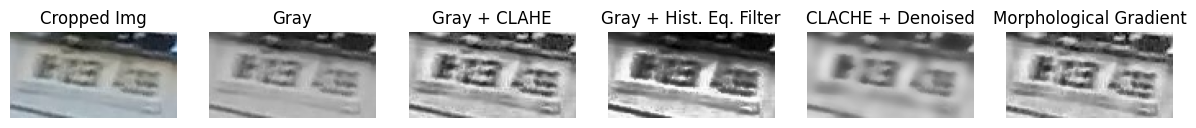

[RAW] -> Text: '珍印' -> Cleaned: '珍印', Conf: 0.1859
[GRAY] -> Text: '三日' -> Cleaned: '三日', Conf: 0.2647
[GRAY + CLAHE] -> Text: 'S印' -> Cleaned: 'S印', Conf: 0.2448
[DEBUG] Could not parse OCR result for 'gray + histeq'
[DEBUG] Could not parse OCR result for 'clahe + denoised'
[MORPHOLOGICAL] -> Text: '印' -> Cleaned: '印', Conf: 0.6626
[INFO] '印' using 'morphological' seems short. So now, analyzing all results...
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/video3_1150_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/morphological/video3_1150_0.jpg
[SUCCESS] video3_1150.jpg: '印', '0.6626', (Length: 1)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/video3_1150.jpg'
[INFO] Running OCR on GJ4.jpg...


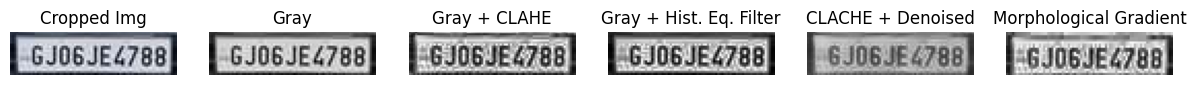

[RAW] -> Text: 'GJ06JE4788' -> Cleaned: 'GJ06JE4788', Conf: 0.9920
[GRAY] -> Text: 'GJ06JE4788' -> Cleaned: 'GJ06JE4788', Conf: 0.9934
[GRAY + CLAHE] -> Text: 'GJ06JE478' -> Cleaned: 'GJ06JE478', Conf: 0.9855
[GRAY + HISTEQ] -> Text: 'GJ06JE4788' -> Cleaned: 'GJ06JE4788', Conf: 0.9751
[CLAHE + DENOISED] -> Text: 'GJ06JE4786' -> Cleaned: 'GJ06JE4786', Conf: 0.9253
[MORPHOLOGICAL] -> Text: 'GJ06JE4789' -> Cleaned: 'GJ06JE4789', Conf: 0.9292
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/GJ4_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/gray/GJ4_0.jpg
[SUCCESS] GJ4.jpg: 'GJ06JE4788', '0.9934', (Length: 10)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/GJ4.jpg'
[INFO] Running OCR on car-wbs-MH01BU5207_00000.jpeg...


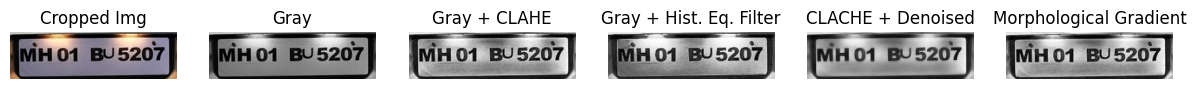

[RAW] -> Text: 'MH 01' -> Cleaned: 'MH01', Conf: 0.9234
[GRAY] -> Text: 'MH 01' -> Cleaned: 'MH01', Conf: 0.8923
[GRAY + CLAHE] -> Text: 'MH01 BU5207' -> Cleaned: 'MH01BU5207', Conf: 0.9635
[GRAY + HISTEQ] -> Text: '200' -> Cleaned: '200', Conf: 0.1404
[CLAHE + DENOISED] -> Text: 'MH 01 BU5207' -> Cleaned: 'MH01BU5207', Conf: 0.9763
[MORPHOLOGICAL] -> Text: 'MH01 BU5207' -> Cleaned: 'MH01BU5207', Conf: 0.9630
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/car-wbs-MH01BU5207_00000_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/clahe + denoised/car-wbs-MH01BU5207_00000_0.jpg
[SUCCESS] car-wbs-MH01BU5207_00000.jpeg: 'MH01BU5207', '0.9763', (Length: 10)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/car-wbs-MH01BU5207_00000.jpeg'
[INFO] Running OCR on 0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpeg...


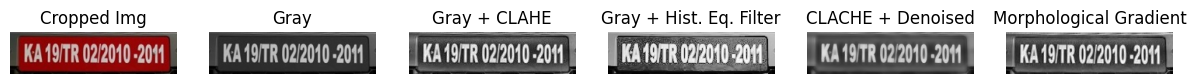

[RAW] -> Text: 'KA19/TR02/2010-2011' -> Cleaned: 'KA19TR0220102011', Conf: 0.9741
[GRAY] -> Text: 'KA19/TR02/2010-2011' -> Cleaned: 'KA19TR0220102011', Conf: 0.9824
[GRAY + CLAHE] -> Text: 'KA19/TR 02/2010-2011' -> Cleaned: 'KA19TR0220102011', Conf: 0.9577
[GRAY + HISTEQ] -> Text: '120-02000100000' -> Cleaned: '12002000100000', Conf: 0.2387
[CLAHE + DENOISED] -> Text: 'KA 19/TR 02/2010-2011' -> Cleaned: 'KA19TR0220102011', Conf: 0.9269
[MORPHOLOGICAL] -> Text: 'KA19/TR 02/2010-2011' -> Cleaned: 'KA19TR0220102011', Conf: 0.9551
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/gray/0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg_0.jpg
[SUCCESS] 0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpeg: 'KA19TR0220102011', '0.9824', (Length: 16)
[INFO] Annotated image saved to

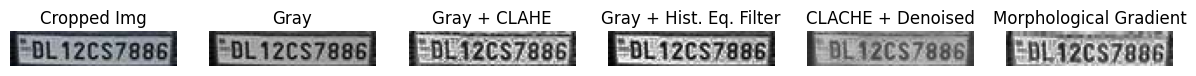

[RAW] -> Text: '1803135500' -> Cleaned: '1803135500', Conf: 0.2255
[GRAY] -> Text: '2883235570' -> Cleaned: '2883235570', Conf: 0.2286
[DEBUG] Could not parse OCR result for 'gray + clahe'
[DEBUG] Could not parse OCR result for 'gray + histeq'
[CLAHE + DENOISED] -> Text: '988323558' -> Cleaned: '988323558', Conf: 0.2686
[MORPHOLOGICAL] -> Text: 'BL12CS788' -> Cleaned: 'BL12CS788', Conf: 0.9515
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/DL21_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/morphological/DL21_0.jpg
[SUCCESS] DL21.jpg: 'BL12CS788', '0.9515', (Length: 9)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/DL21.jpg'
[INFO] Running OCR on video8_2350.jpg...


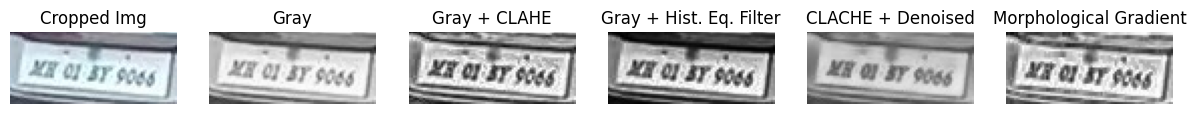

[RAW] -> Text: '990681OEX' -> Cleaned: '990681OEX', Conf: 0.6204
[GRAY] -> Text: '9906810E' -> Cleaned: '9906810E', Conf: 0.6736
[GRAY + CLAHE] -> Text: '990610EX' -> Cleaned: '990610EX', Conf: 0.6807
[GRAY + HISTEQ] -> Text: '990610 EK' -> Cleaned: '990610EK', Conf: 0.6478
[CLAHE + DENOISED] -> Text: '9906008' -> Cleaned: '9906008', Conf: 0.7683
[MORPHOLOGICAL] -> Text: '990610EK' -> Cleaned: '990610EK', Conf: 0.7354
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/video8_2350_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/clahe + denoised/video8_2350_0.jpg
[SUCCESS] video8_2350.jpg: '9906008', '0.7683', (Length: 7)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/video8_2350.jpg'
[INFO] Running OCR on video3_1930.jpg...


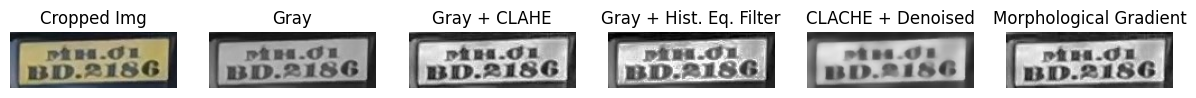

[RAW] -> Text: '盒.0' -> Cleaned: '盒0', Conf: 0.3931
[GRAY] -> Text: 'P盒.On' -> Cleaned: 'P盒ON', Conf: 0.4264
[GRAY + CLAHE] -> Text: 'D盒.O' -> Cleaned: 'D盒O', Conf: 0.5185
[GRAY + HISTEQ] -> Text: '.01' -> Cleaned: '01', Conf: 0.7457
[CLAHE + DENOISED] -> Text: '0' -> Cleaned: '0', Conf: 0.6567
[MORPHOLOGICAL] -> Text: 'P.0n' -> Cleaned: 'P0N', Conf: 0.5537
[INFO] '01' using 'gray + histeq' seems short. So now, analyzing all results...
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/video3_1930_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/gray + histeq/video3_1930_0.jpg
[SUCCESS] video3_1930.jpg: '01', '0.7457', (Length: 2)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/video3_1930.jpg'
[INFO] Running OCR on car-wbs-MH20DV2362_00000.jpeg...


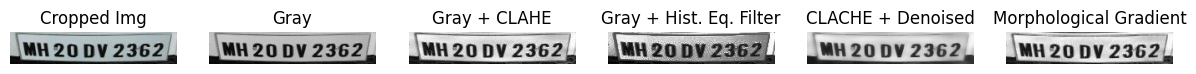

[RAW] -> Text: '20000' -> Cleaned: '20000', Conf: 0.1962
[GRAY] -> Text: '20000200' -> Cleaned: '20000200', Conf: 0.2352
[GRAY + CLAHE] -> Text: '2000200' -> Cleaned: '2000200', Conf: 0.2318
[GRAY + HISTEQ] -> Text: 'MH20DV2362' -> Cleaned: 'MH20DV2362', Conf: 0.9857
[CLAHE + DENOISED] -> Text: '1200020' -> Cleaned: '1200020', Conf: 0.2021
[MORPHOLOGICAL] -> Text: '3205005' -> Cleaned: '3205005', Conf: 0.2496
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/car-wbs-MH20DV2362_00000_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/gray + histeq/car-wbs-MH20DV2362_00000_0.jpg
[SUCCESS] car-wbs-MH20DV2362_00000.jpeg: 'MH20DV2362', '0.9857', (Length: 10)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/car-wbs-MH20DV2362_00000.jpeg'
[INFO] Running OCR on video3_1350.jpg...


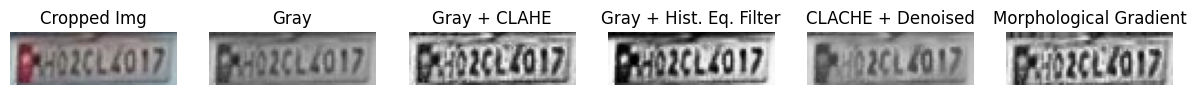

[RAW] -> Text: '21077320' -> Cleaned: '21077320', Conf: 0.3391
[GRAY] -> Text: '210773201' -> Cleaned: '210773201', Conf: 0.3582
[DEBUG] Could not parse OCR result for 'gray + clahe'
[DEBUG] Could not parse OCR result for 'gray + histeq'
[CLAHE + DENOISED] -> Text: '21071370' -> Cleaned: '21071370', Conf: 0.4907
[DEBUG] Could not parse OCR result for 'morphological'
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/video3_1350_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/clahe + denoised/video3_1350_0.jpg
[SUCCESS] video3_1350.jpg: '21071370', '0.4907', (Length: 8)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/video3_1350.jpg'
[INFO] Running OCR on video11_4080.jpg...


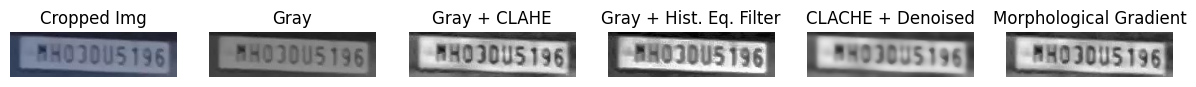

[RAW] -> Text: 'MHOJDU5196' -> Cleaned: 'MHOJDU5196', Conf: 0.8336
[GRAY] -> Text: 'MHO3DU5196' -> Cleaned: 'MHO3DU5196', Conf: 0.7947
[GRAY + CLAHE] -> Text: 'MHO30U5196' -> Cleaned: 'MHO30U5196', Conf: 0.8736
[GRAY + HISTEQ] -> Text: 'MHO30U519' -> Cleaned: 'MHO30U519', Conf: 0.8237
[CLAHE + DENOISED] -> Text: '鄂HOJDU5196' -> Cleaned: '鄂HOJDU5196', Conf: 0.8547
[MORPHOLOGICAL] -> Text: 'MHO30U5196' -> Cleaned: 'MHO30U5196', Conf: 0.8408
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/video11_4080_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/gray + clahe/video11_4080_0.jpg
[SUCCESS] video11_4080.jpg: 'MHO30U5196', '0.8736', (Length: 10)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/video11_4080.jpg'
[INFO] Running OCR on video11_790.jpg...


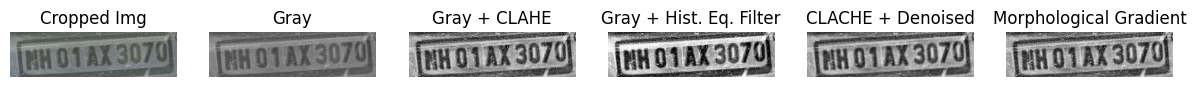

[RAW] -> Text: 'OOS2A2E' -> Cleaned: 'OOS2A2E', Conf: 0.1204
[GRAY] -> Text: 'AOS2A2E' -> Cleaned: 'AOS2A2E', Conf: 0.1181
[GRAY + CLAHE] -> Text: 'OS0AA' -> Cleaned: 'OS0AA', Conf: 0.1332
[GRAY + HISTEQ] -> Text: '0SX0AO' -> Cleaned: '0SX0AO', Conf: 0.1285
[CLAHE + DENOISED] -> Text: '01AX307' -> Cleaned: '01AX307', Conf: 0.9162


Processing Batches:   7%|▋         | 1/15 [04:20<1:00:51, 260.86s/it]

[MORPHOLOGICAL] -> Text: 'OS0A1' -> Cleaned: 'OS0A1', Conf: 0.1148
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/crop/video11_790_0.jpg
[INFO] Debug image saved to: '/content/results_v1/paddleOCR/ocr_debug_images/clahe + denoised/video11_790_0.jpg
[SUCCESS] video11_790.jpg: '01AX307', '0.9162', (Length: 7)
[INFO] Annotated image saved to: '/content/results_v1/paddleOCR/ocr_output_images/video11_790.jpg'
[DEBUG] Batch results received: 12 results
[STATS] OCR Success: 12, Failures: 0, No Detections: 0
[INFO] Processing batch 2/15...
[INFO] Running YOLO detection on batch of 12 images...


Processing Batches:   7%|▋         | 1/15 [04:30<1:03:07, 270.52s/it]


KeyboardInterrupt: 

In [42]:
if __name__ == "__main__":
    # Configuration
    MODEL_PATH = "/content/models/best.pt"
    IMG_DIR = "/content/data/processed/images/test/"
    OUTPUT_DIR = "/content/results_v1/paddleOCR/"
    CSV_PATH = "/content/results_v1/ocr_results.csv"
    CONF_THRESH_DET = 0.5
    CONF_THRESH_REC = 0.3
    BATCH_SIZE = 12
    MAX_WORKERS = 4

    # Initialize pipeline
    pipeline = ANPRPipeline(MODEL_PATH, OUTPUT_DIR, CSV_PATH)

    # Process images
    pipeline.process_directory(
        img_dir=IMG_DIR,
        batch_size=BATCH_SIZE,
        conf_threshold_det=CONF_THRESH_DET,
        conf_threshold_rec=CONF_THRESH_REC,
        max_workers=MAX_WORKERS,
    )

In [43]:
shutil.rmtree('/content/results_v1')

In [ ]:
# from IPython.display import display, Image

# image_paths = [
#     "/content/data/example/DL3.jpg",
#     "/content/data/example/debug_DL3_0.jpg",
# ]

# for path in image_paths:
#     try:
#         display(Image(filename=path))
#         print(f"Displayed: {path}")
#     except FileNotFoundError:
#         print(f"File not found: {path}")
#     except Exception as e:
#         print(f"Error displaying {path}: {e}")

Dry run for individual images

In [ ]:
def validate_crop(cropped_img: np.ndarray, min_area: int = 100) -> bool:
      if cropped_img is None or cropped_img.size == 0:
        return False

      h, w = cropped_img.shape[:2]
      if h < 10 or w < 20 or (h * w) < min_area:
        return False

      # Check if image is not completely black or white
      mean_val = np.mean(cropped_img)
      if mean_val < 5 or mean_val > 250:
        return False

      return True

def show_images(images, titles):
    plt.figure(figsize=(15, 5))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:  # grayscale
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()

def preprocess_variants(cropped_img: np.ndarray):
    try:
      if not validate_crop(cropped_img):
        return None

      variants = {"raw": cropped_img}

      # Grayscale
      gray = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)
      variants["gray"] = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

      # Grayscale + CLAHE
      clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
      clahe_img = clahe.apply(gray)
      variants["gray + clahe"] = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2BGR)

      # # Histogram Equalization
      # hist_eq = cv2.equalizeHist(gray)
      # variants["gray + histeq"] = cv2.cvtColor(hist_eq, cv2.COLOR_GRAY2BGR)

      # Bilateral Filter + CLAHE
      denoised = cv2.bilateralFilter(clahe_img, 9, 75, 75)
      variants["clache + denoised"] = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)

      # # Adaptive thresholding + Morphological clean up + Denoised
      # thresh = cv2.adaptiveThreshold(
      #     denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
      #     cv2.THRESH_BINARY, 11, 2
      # )
      # kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
      # cleaned = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)
      # variants["denoised + adaptive thresholding"] = cv2.cvtColor(cleaned, cv2.COLOR_GRAY2BGR)

      # # Resize + Denoised
      # h, w = cleaned.shape
      # if h < 32:  # min height
      #   scale_factor = 32 / h
      #   new_w = int(w * scale_factor)
      #   resized = cv2.resize(denoised, (new_w, 32), interpolation=cv2.INTER_CUBIC)
      # variants["denoised + resized"] = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)

      # # Display inline if in notebook
      # show_images(
      #   [cropped_img, variants["gray"], variants["gray + clahe"], variants["gray + histeq"], variants["clache + denoised"], variants["denoised + adaptive thresholding"], variants["denoised + resized"]],
      #   ["Cropped Img", "Gray", "Gray + CLACHE", "Gray + Morphological Gradient", "CLACHE + Denoised", "Denoised + Adaptive Thresholding", "Denoised + Resized"]
      # )

      return variants
    except Exception as e:
      print(f"[DEBUG] Preprocessing failed: {e}")
      return None

def ocr_image(cropped_img: np.ndarray) -> Tuple[Optional[str], float]:
    ocr = PaddleOCR(lang='en', use_textline_orientation=False)
    result = ocr.predict(cropped_img)
    try:
        text = result[0]['rec_texts'][0]
        confidence = result[0]['rec_scores'][0]
        return text, confidence
    except:
        print(f"[DEBUG] OCR failed: {result}")
        return None, 0.0

def smart_ocr(cropped_img: str) -> Tuple[str, float, str]:
    img = cv2.imread(cropped_img)
    if img is None:
        raise ValueError(f"Could not read image: {cropped_img}")

    variants = preprocess_variants(img)

    best_text, best_conf, best_variant = "", 0.0, ""
    for name, variant in variants.items():
        text, conf = ocr_image(variant)
        print(f"[{name.upper()}] -> Text: {text}, Conf: {conf:.4f}")
        if conf > best_conf:
            best_text, best_conf, best_variant = text, conf, name

    return best_text, best_conf, best_variant


crp_img = "/content/data/example/debug_DL3_0.jpg"
best_text, best_conf, variant = smart_ocr(crp_img)
print(f"\n[FINAL RESULT] Best Text: {best_text}, Confidence: {best_conf:.4f}, Variant: {variant}")

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None)
The model(UVDoc) is not supported to run in MKLDNN mode! Using `paddle` instead!
Using official model (UVDoc), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


...

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in /root/.paddlex/official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

[CLACHE + DENOISED] -> Text: OL8CAU68, Conf: 0.8675

[FINAL RESULT] Best Text: OL8CAU688, Confidence: 0.9334, Variant: gray


In [ ]:
from google.colab import files

def runs_collab(folder_name="results_v1", output_name="results_v1.zip"):
    if not os.path.exists(folder_name):
        print(f"[ERROR] Folder '{folder_name}' does not exist.")
        return

    # Create the zip file
    print(f"[INFO] Zipping folder '{folder_name}'...")
    os.system(f"zip -r {output_name} {folder_name}")

    # Download the zip file
    if os.path.exists(output_name):
        print(f"[INFO] Downloading '{output_name}'...")
        files.download(output_name)
    else:
        print("[ERROR] Failed to create zip file.")

runs_collab()